In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.extract import load_json
from src.transform import clean_data
from src.analysis import *
from src.visualization import *

ModuleNotFoundError: No module named 'src'

#📌 Extracción

In [9]:
# ==========================================
# FASE 1 — EXTRACCIÓN DE DATOS DESDE LA API
# ==========================================

import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Cargar JSON como lista de diccionarios
data = pd.read_json(url)

# Aplanar completamente el JSON
df = pd.json_normalize(data.to_dict(orient="records"))

# Ver primeras filas
print("Primeras filas del dataset:")
print(df.head())

Primeras filas del dataset:
   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   

  in

#🔧 Transformación

In [10]:
# ==========================================
# FASE 2 — EXPLORACIÓN DE LOS DATOS
# ==========================================

print("\nDimensiones del dataset:")
print(df.shape)

print("\nColumnas del dataset:")
print(df.columns)

print("\nTipos de datos:")
print(df.dtypes)

print("\nInformación general:")
df.info()

# ==========================================
# DETECCIÓN DE INCONSISTENCIAS
# ==========================================

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nNúmero de duplicados:")
print(df.duplicated().sum())

# Eliminar duplicados si existen
df = df.drop_duplicates()

# ==========================================
# REVISIÓN DE VALORES ÚNICOS
# ==========================================

categorical_columns = [
    "Churn",
    "customer.gender",
    "customer.Partner",
    "customer.Dependents",
    "phone.PhoneService",
    "internet.InternetService",
    "account.Contract",
    "account.PaymentMethod"
]

for col in categorical_columns:
    print(f"\nValores únicos en {col}:")
    print(df[col].unique())

# ==========================================
# LIMPIEZA DE DATOS
# ==========================================

# Revisar Charges.Total
print("\nValores únicos en Charges.Total:")
print(df["account.Charges.Total"].unique())

# Reemplazar espacios vacíos
df["account.Charges.Total"] = df["account.Charges.Total"].replace(" ", None)

# Convertir a numérico
df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"], errors="coerce"
)

# Rellenar valores nulos con mediana
df["account.Charges.Total"].fillna(
    df["account.Charges.Total"].median(), inplace=True
)

# Convertir SeniorCitizen a categoría
df["customer.SeniorCitizen"] = df["customer.SeniorCitizen"].replace({
    0: "No",
    1: "Yes"
})

# ==========================================
# VERIFICACIÓN POST-LIMPIEZA
# ==========================================

print("\nInformación del dataset después de limpieza:")
df.info()

print("\nValores nulos después de limpieza:")
print(df.isnull().sum())

# ==========================================
# CREAR COLUMNA CUENTAS DIARIAS (OPCIONAL)
# ==========================================

df["Cuentas_Diarias"] = df["account.Charges.Monthly"] / 30

print("\nEjemplo de facturación diaria:")
print(df[["account.Charges.Monthly", "Cuentas_Diarias"]].head())

# ==========================================
# ESTANDARIZACIÓN DE DATOS (OPCIONAL)
# ==========================================

# Convertir churn a variable binaria
df["Churn_Binary"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

# Convertir algunas variables binarias
binary_columns = [
    "customer.Partner",
    "customer.Dependents",
    "phone.PhoneService",
    "account.PaperlessBilling"
]

for col in binary_columns:
    df[col] = df[col].map({
        "Yes": 1,
        "No": 0
    })

# ==========================================
# REVISIÓN FINAL
# ==========================================

print("\nPrimeras filas del dataset final:")
print(df.head())

print("\nResumen estadístico:")
print(df.describe())


Dimensiones del dataset:
(7267, 21)

Columnas del dataset:
Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='str')

Tipos de datos:
customerID                       str
Churn                            str
customer.gender                  str
customer.SeniorCitizen         int64
customer.Partner                 str
customer.Dependents              str
customer.tenure                int64
phone.PhoneService               str
phone.MultipleLines              str
internet.InternetService     

C:\Users\oswan\AppData\Local\Temp\ipykernel_13244\1857310872.py:66: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["account.Charges.Total"].fillna(


#📊 Carga y análisis

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

print("Resumen estadístico del dataset:")
df.describe(include="all")

df["Churn"].value_counts()

Resumen estadístico del dataset:


Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

#📊 Gráfico de distribución de churn

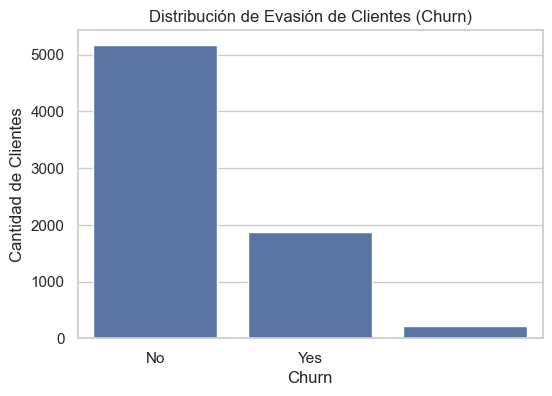

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Distribución de Evasión de Clientes (Churn)")
plt.xlabel("Churn")
plt.ylabel("Cantidad de Clientes")

plt.show()

#📊 Gráfico de proporción

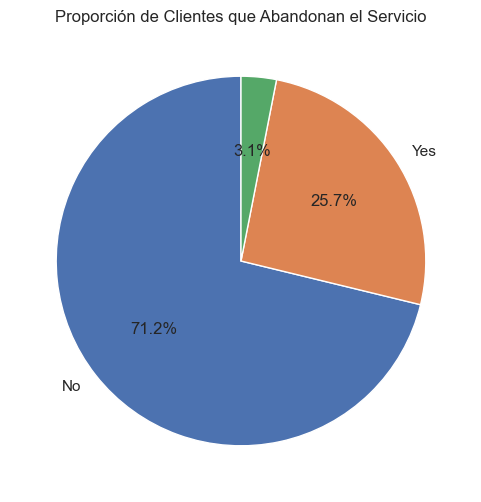

In [24]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Proporción de Clientes que Abandonan el Servicio")

plt.show()

#📊 Churn por género

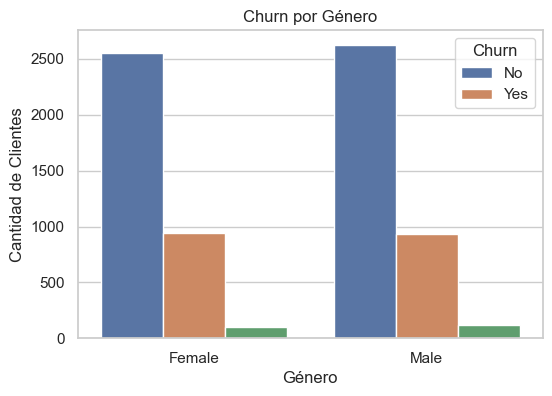

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="customer.gender",
    hue="Churn"
)

plt.title("Churn por Género")
plt.xlabel("Género")
plt.ylabel("Cantidad de Clientes")

plt.show()

#📊 Churn por tipo de contrato

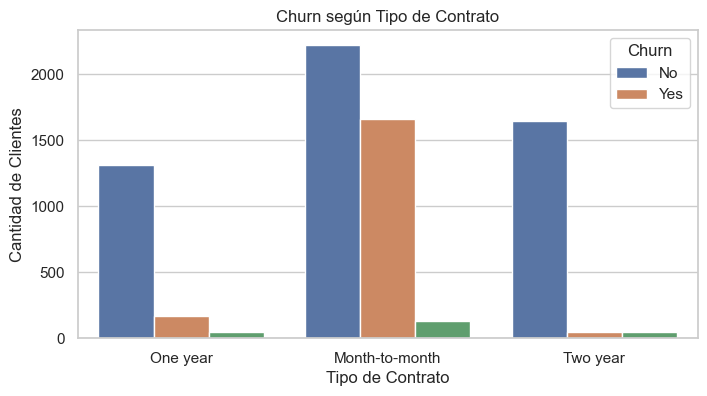

In [21]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="account.Contract",
    hue="Churn"
)

plt.title("Churn según Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Cantidad de Clientes")

plt.show()

#📊 Churn por método de pago

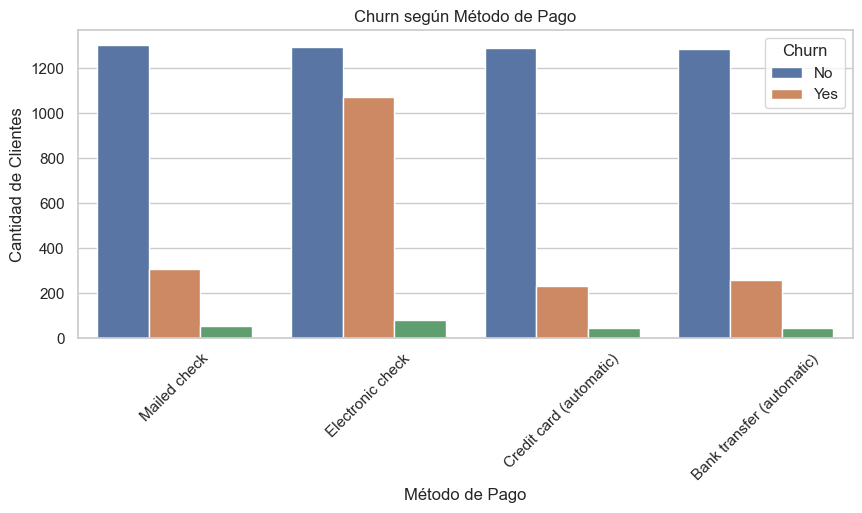

In [22]:
plt.figure(figsize=(10,4))

sns.countplot(
    data=df,
    x="account.PaymentMethod",
    hue="Churn"
)

plt.title("Churn según Método de Pago")
plt.xlabel("Método de Pago")
plt.ylabel("Cantidad de Clientes")

plt.xticks(rotation=45)

plt.show()

#📊 Churn por servicio de internet

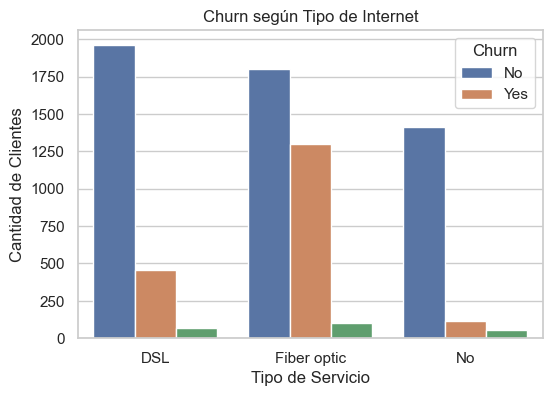

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="internet.InternetService",
    hue="Churn"
)

plt.title("Churn según Tipo de Internet")
plt.xlabel("Tipo de Servicio")
plt.ylabel("Cantidad de Clientes")

plt.show()

#📊 Churn vs cargos mensuales

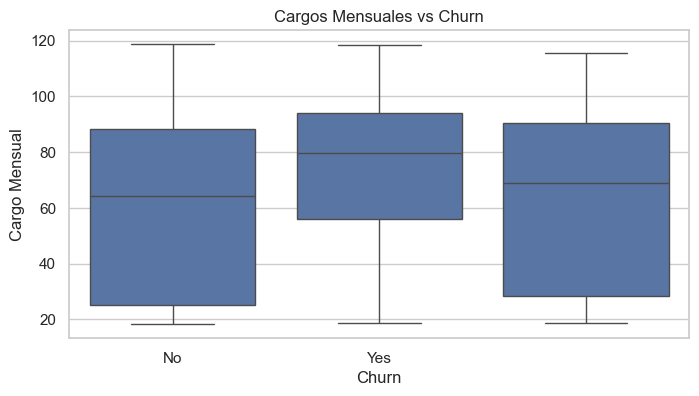

In [20]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df,
    x="Churn",
    y="account.Charges.Monthly"
)

plt.title("Cargos Mensuales vs Churn")
plt.xlabel("Churn")
plt.ylabel("Cargo Mensual")

plt.show()

#📄Informe final

Introducción

El objetivo de este análisis es comprender los factores que influyen en la evasión de clientes (Churn) en la empresa TelecomX.

La evasión de clientes representa uno de los principales problemas para las empresas de telecomunicaciones, ya que implica la pérdida de ingresos y mayores costos para adquirir nuevos clientes.

A través de técnicas de análisis exploratorio de datos (EDA), se busca identificar patrones en el comportamiento de los clientes que puedan explicar por qué algunos deciden cancelar el servicio.

Limpieza y tratamiento de datos

Los datos fueron obtenidos desde una API en formato JSON. Posteriormente se realizó la normalización de la estructura del JSON para convertir los datos en un DataFrame de Pandas.

Durante el proceso de limpieza se realizaron las siguientes acciones:

- Normalización de datos anidados utilizando json_normalize
- Revisión de valores nulos
- Conversión de la columna Charges.Total a tipo numérico
- Eliminación de duplicados
- Creación de la variable Cuentas_Diarias
- Transformación de variables binarias para facilitar el análisis

Análisis Exploratorio de Datos

Se realizaron diferentes análisis para comprender la distribución de la evasión de clientes.

Se analizaron variables como:

- Género
- Tipo de contrato
- Método de pago
- Tipo de servicio de internet
- Cargos mensuales

Los gráficos permitieron identificar patrones relevantes en el comportamiento de los clientes.

Conclusiones e Insights

A partir del análisis exploratorio se identificaron los siguientes hallazgos:

1. Los clientes con contratos mensuales presentan una mayor tasa de evasión en comparación con los contratos anuales.

2. Algunos métodos de pago presentan mayor concentración de clientes que abandonan el servicio.

3. Los clientes con cargos mensuales más altos tienden a presentar mayor probabilidad de churn.

4. El tipo de servicio de internet también influye en la evasión de clientes.